# HDB Resale Price Regression — Notebook 15: The 168 Question

`price_has_168` (一路发, "prosperity all the way") was dropped in Model 11 because it failed median regression on the full sample (OLS: +$32,795, LAD: +$17,233, p = 0.198). But the trailing-8 premium grows sharply with price — maybe 168 does too.

This notebook scopes to higher-priced transactions to see if the 168 effect is real among expensive flats but diluted by cheap ones.

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(sandwich)
library(lmtest)
library(quantreg)

df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
df$remaining_lease_sq <- df$remaining_lease_years^2
df$month_factor <- factor(format(df$month, '%Y-%m'))

cat(sprintf('Loaded %s rows\n', format(nrow(df), big.mark = ',')))
cat(sprintf('Transactions with 168 in price: %d (%.1f%%)\n',
    sum(df$price_has_168 == 1), mean(df$price_has_168) * 100))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loaded 50,718 rows


Transactions with 168 in price: 103 (0.2%)


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: SparseM


## Where does 168 appear?

First question: how are 168-containing prices distributed across the price spectrum? If they only appear among expensive flats, the full-sample test was diluted by a huge mass of non-168 cheap transactions.

In [3]:
%%R
# Create price quartiles based on predicted price (no superstition vars)
model_base <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              month_factor,
            data = df)

df$pred_base <- predict(model_base, df)
df$price_quartile <- cut(df$pred_base,
    breaks = quantile(df$pred_base, probs = c(0, 0.25, 0.5, 0.75, 1)),
    labels = c('Q1', 'Q2', 'Q3', 'Q4'),
    include.lowest = TRUE)

cat(sprintf('%-20s %8s %8s %10s %12s\n',
    'Quartile', 'N', 'Has 168', '% with 168', 'Avg price'))
cat(paste(rep('-', 62), collapse = ''), '\n')

for (q in levels(df$price_quartile)) {
    subset <- df[df$price_quartile == q, ]
    n_168 <- sum(subset$price_has_168 == 1)
    cat(sprintf('%-20s %8d %8d %9.1f%% $%10s\n',
        q, nrow(subset), n_168,
        n_168 / nrow(subset) * 100,
        format(round(mean(subset$resale_price)), big.mark = ',')))
}

cat(sprintf('\n%-20s %8d %8d %9.1f%%\n', 'TOTAL',
    nrow(df), sum(df$price_has_168 == 1),
    mean(df$price_has_168) * 100))

# Also show by decile for finer grain
cat('\n\nBy price decile:\n')
df$price_decile <- cut(df$pred_base,
    breaks = quantile(df$pred_base, probs = seq(0, 1, 0.1)),
    labels = paste0('D', 1:10),
    include.lowest = TRUE)

cat(sprintf('%-10s %8s %8s %10s\n', 'Decile', 'N', 'Has 168', '% with 168'))
cat(paste(rep('-', 40), collapse = ''), '\n')
for (d in levels(df$price_decile)) {
    subset <- df[df$price_decile == d, ]
    n_168 <- sum(subset$price_has_168 == 1)
    cat(sprintf('%-10s %8d %8d %9.1f%%\n',
        d, nrow(subset), n_168, n_168 / nrow(subset) * 100))
}

Quartile                    N  Has 168 % with 168    Avg price


--------------------------------------------------------------

Q1                      12680       17       0.1% $   421,531


Q2                      12679       22       0.2% $   564,405


Q3                      12679       28       0.2% $   677,417


...

D6             5072       11       0.2%


D7             5071       12       0.2%


D8             5072        7       0.1%


D9             5072        7       0.1%


D10            5072       27       0.5%


## 168 premium by price quartile

Same approach as the trailing-8 interaction in NB13/14: interact `price_has_168` with price quartile to see if the effect differs by price level.

In [4]:
%%R
# Full model with 168 × quartile interaction
model_168_int <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 * price_quartile +
              month_factor,
            data = df)

robust_168 <- coeftest(model_168_int, vcov = vcovHC(model_168_int, type = 'HC1'))

base_168 <- robust_168['price_has_168', 'Estimate']
cat(sprintf('"168" premium by price quartile (OLS, robust SEs):\n\n'))
cat(sprintf('%-30s %12s %10s\n', 'Quartile', '168 premium', 'p-value'))
cat(paste(rep('-', 55), collapse = ''), '\n')

cat(sprintf('%-30s $%+10.0f %10.4f\n', 'Q1 (cheapest 25%)',
    base_168, robust_168['price_has_168', 'Pr(>|t|)']))

for (q in c('Q2', 'Q3', 'Q4')) {
    int_name <- sprintf('price_has_168:price_quartile%s', q)
    if (int_name %in% rownames(robust_168)) {
        total <- base_168 + robust_168[int_name, 'Estimate']
        p_int <- robust_168[int_name, 'Pr(>|t|)']
        cat(sprintf('%-30s $%+10.0f %10.4f (interaction p)\n',
            q, total, p_int))
    }
}

# Also show: num_eights_tail in this model (should be stable)
cat(sprintf('\nnum_eights_tail in this model: $%+.0f (p = %.4f)\n',
    robust_168['num_eights_tail', 'Estimate'],
    robust_168['num_eights_tail', 'Pr(>|t|)']))

"168" premium by price quartile (OLS, robust SEs):



Quartile                        168 premium    p-value


-------------------------------------------------------

Q1 (cheapest 25%)              $     +5777     0.7002


Q2                             $     +4575     0.9478 (interaction p)


Q3                             $     +6667     0.9610 (interaction p)


Q4                             $    +80936     0.0002 (interaction p)



num_eights_tail in this model: $+1105 (p = 0.0000)


## LAD regression on upper half only

The full-sample LAD killed 168 (p = 0.198). Does scoping to the upper half (Q3 + Q4) change that? This is where 168-ending prices are most common and where buyers are most likely to pay for auspicious numbers.

In [5]:
%%R
# Upper half: Q3 + Q4
df_upper <- df[df$price_quartile %in% c('Q3', 'Q4'), ]
cat(sprintf('Upper half: %s transactions (Q3 + Q4)\n',
    format(nrow(df_upper), big.mark = ',')))
cat(sprintf('168 transactions in upper half: %d (%.1f%%)\n\n',
    sum(df_upper$price_has_168 == 1),
    mean(df_upper$price_has_168) * 100))

# OLS on upper half
model_upper_ols <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              month_factor,
            data = df_upper)

# LAD on upper half
cat('Fitting LAD on upper half...\n')
model_upper_lad <- rq(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              month_factor,
            tau = 0.5, method = 'fn',
            data = df_upper)
cat('Done.\n\n')

lad_summary <- summary(model_upper_lad, se = 'nid')

robust_upper <- coeftest(model_upper_ols, vcov = vcovHC(model_upper_ols, type = 'HC1'))

# Compare OLS vs LAD for key vars
cat(sprintf('%-25s %12s %8s %12s %8s\n', 'Variable', 'OLS ($)', 'OLS p', 'LAD ($)', 'LAD p'))
cat(paste(rep('-', 68), collapse = ''), '\n')

for (v in c('num_eights_tail', 'price_has_168')) {
    c_ols <- robust_upper[v, 'Estimate']
    p_ols <- robust_upper[v, 'Pr(>|t|)']

    c_lad <- coef(model_upper_lad)[v]
    p_lad <- tryCatch(lad_summary$coefficients[v, 4], error = function(e) NA)

    p_lad_str <- ifelse(is.na(p_lad), '--', sprintf('%.4f', p_lad))
    cat(sprintf('%-25s $%+10.0f %7.4f $%+10.0f %8s\n',
        v, c_ols, p_ols, c_lad, p_lad_str))
}

Upper half: 25,359 transactions (Q3 + Q4)


168 transactions in upper half: 64 (0.3%)



Fitting LAD on upper half...


Done.



Variable                       OLS ($)    OLS p      LAD ($)    LAD p


--------------------------------------------------------------------

num_eights_tail           $     +1637  0.0000 $     +1464   0.0000


price_has_168             $    +28371  0.0001 $    +30526   0.0591


In addition: Warning messages:
1: In rq.fit.fnb(x, y, tau = tau, ...) :
  Error info =  31 in stepy: possibly singular design
2: In summary.rq(model_upper_lad, se = "nid") : 15 non-positive fis


In [6]:
%%R
# Q4 only (most expensive 25%)
df_q4 <- df[df$price_quartile == 'Q4', ]
cat(sprintf('Q4 only: %s transactions\n', format(nrow(df_q4), big.mark = ',')))
cat(sprintf('168 transactions in Q4: %d (%.1f%%)\n\n',
    sum(df_q4$price_has_168 == 1),
    mean(df_q4$price_has_168) * 100))

# OLS on Q4
model_q4_ols <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              month_factor,
            data = df_q4)

robust_q4 <- coeftest(model_q4_ols, vcov = vcovHC(model_q4_ols, type = 'HC1'))

cat(sprintf('%-25s %12s %8s\n', 'Variable', 'OLS ($)', 'p-value'))
cat(paste(rep('-', 48), collapse = ''), '\n')

for (v in c('num_eights_tail', 'price_has_168')) {
    c_ols <- robust_q4[v, 'Estimate']
    p_ols <- robust_q4[v, 'Pr(>|t|)']
    sig <- ifelse(p_ols < 0.05, '*', '')
    cat(sprintf('%-25s $%+10.0f %7.4f %s\n', v, c_ols, p_ols, sig))
}

Q4 only: 12,680 transactions


168 transactions in Q4: 36 (0.3%)



Variable                       OLS ($)  p-value


------------------------------------------------

num_eights_tail           $     +1694  0.0018 *


price_has_168             $    +34079  0.0004 *


In addition: Warning message:
In meatHC(x, type = type, omega = omega) :
  HC1 covariances become (close to) singular if hat values are (close to) 1 as for observation(s) 11909


### Verdict

The 168 finding is real, but it is sharply concentrated at the top of the market and should be reported with that caveat.

**Distribution is roughly flat — until you hit the very top.** Across Q1 through Q3, 168-ending prices appear at a fairly even rate of 0.1–0.2% of transactions. The picture only shifts dramatically in D10 (the top decile), where the rate jumps to 0.5% — more than double the sample average. That pattern is consistent with sellers and buyers in the priciest segment being more deliberate about auspicious pricing, but it also means the 168 signal is extremely thin in the bottom three quartiles. The full-sample test was indeed diluted: you are asking 103 transactions to speak for a dataset of 50,718, and most of those 103 occur in segments where the signal is noise.

**The quartile interaction tells a clean story — except it is driven entirely by Q4.** In Q1, the 168 premium is +$5,777 (p = 0.70) — statistically indistinguishable from zero. Q2 and Q3 are similarly flat and insignificant. Then Q4 jumps: the 168 premium in the most expensive quartile is **+$80,936** with p = 0.0002. The interaction is large and highly significant, meaning the premium in Q4 is statistically different from Q1 at better than the 1% level. This mirrors the trailing-8 pattern from NB13/NB14, where the 8-ending premium also rose with price — but for 168 the gradient is far steeper and the effect is almost entirely confined to one quartile.

**LAD on the upper half does not quite clear the bar.** Scoped to Q3 + Q4, OLS gives a 168 premium of +$28,371 (p = 0.0001), which is emphatic. The median regression on the same subsample yields +$30,526 — the coefficient actually strengthens — but the p-value is 0.059, just outside the conventional 5% threshold. The LAD also threw warnings (singular design, non-positive fis), flagging that with only 64 transactions bearing 168 in a 25,000-row subsample, the median estimator is working at the edge of its stability. The effect is directionally consistent across both estimators, but the LAD does not provide the clean confirmation you would want before publishing a precise dollar figure.

**Q4 alone is decisive, on OLS.** Among the 12,680 transactions in the top quartile, the 168 premium is **+$34,079** (p = 0.0004). That is a large and statistically robust effect. `num_eights_tail` is also significant at the same scope (+$1,694, p = 0.0018), confirming that auspicious-number effects are real and meaningful in the upper market. The Q4 result is the cleanest evidence in this notebook.

**Bottom line for publication:** 168 should not be reinstated in Model 11 as a whole-sample variable — the full-sample evidence is too weak. But the Q4 finding is solid enough to report as a conditional result: among high-end HDB transactions (top quartile, average resale price ~$906,000), flats sold at a price containing 168 command an OLS premium of about $34,000, significant at well under 1%. The honest framing is "among expensive flats" or "in the top quarter of the market." Avoid quoting a single all-sample number, because it mixes a real Q4 effect with three quartiles of noise. If the story angle is that auspicious-number effects are strongest among buyers who can afford them, the 168 finding in Q4 fits that narrative and stands up statistically — with the caveat that the sample is 36 transactions, so it should be cited as supporting colour rather than a headline figure."

## Dissecting 168: two different phenomena

Not all 168-containing prices are the same. Looking at the 103 transactions, they cluster into distinct price points:

- **$1,168,000 / $1,168,888** — deliberate 一路发 pricing at the ~$1.17M mark
- **$X16,888** — prices ending in 888 where 168 appears incidentally ($816,888, $716,888, $616,888, etc.)

Are these the same thing? Or is the "168 premium" really just the trailing-8 premium with extra steps?

In [7]:
%%R
# Classify 168 transactions
df_168 <- df[df$price_has_168 == 1, ]

# "Deliberate 168": prices at $1,168,000 or $1,168,888 or $1,168,168
# These are sellers who specifically chose the 一路发 number
df_168$type_168 <- ifelse(
    df_168$resale_price >= 1168000 & df_168$resale_price <= 1168888,
    'Deliberate ($1.168M)',
    ifelse(df_168$resale_price %% 1000 == 888 | df_168$resale_price %% 1000 == 688,
        'Incidental (X16,888)',
        'Other 168'))

# Predictions from base model (no superstition vars)
df_168$pred_base <- predict(model_base, df_168)
df_168$gap <- df_168$resale_price - df_168$pred_base
df_168$gap_pct <- round(df_168$gap / df_168$pred_base * 100, 1)

cat(sprintf('%-25s %5s %12s %12s %10s\n',
    'Category', 'N', 'Avg price', 'Avg pred', 'Avg gap'))
cat(paste(rep('-', 67), collapse = ''), '\n')

for (type in c('Deliberate ($1.168M)', 'Incidental (X16,888)', 'Other 168')) {
    subset <- df_168[df_168$type_168 == type, ]
    if (nrow(subset) > 0) {
        cat(sprintf('%-25s %5d $%10s $%10s %+9.1f%%\n',
            type, nrow(subset),
            format(round(mean(subset$resale_price)), big.mark = ','),
            format(round(mean(subset$pred_base)), big.mark = ','),
            mean(subset$gap_pct)))
    }
}

cat(sprintf('\n%-25s %5d $%10s $%10s %+9.1f%%\n',
    'ALL 168', nrow(df_168),
    format(round(mean(df_168$resale_price)), big.mark = ','),
    format(round(mean(df_168$pred_base)), big.mark = ','),
    mean(df_168$gap_pct)))

Category                      N    Avg price     Avg pred    Avg gap


-------------------------------------------------------------------

Deliberate ($1.168M)         24 $ 1,168,192 $ 1,020,956     +14.6%


Incidental (X16,888)         58 $   620,647 $   620,987      +1.9%


Other 168                    21 $   632,103 $   630,274      +0.6%



ALL 168                     103 $   750,566 $   716,077      +4.6%


In [8]:
%%R
# The deliberate 168 cluster
deliberate <- df_168[df_168$type_168 == 'Deliberate ($1.168M)', ]
deliberate <- deliberate[order(-deliberate$gap_pct), ]

cat(sprintf('=== The $1,168,000 / $1,168,888 cluster (%d transactions) ===\n\n', nrow(deliberate)))
cat(sprintf('%-8s %-6s %-22s %-10s %12s %12s %8s\n',
    'Month', 'Block', 'Street', 'Type', 'Price', 'Predicted', 'Gap'))
cat(paste(rep('-', 84), collapse = ''), '\n')

for (i in 1:nrow(deliberate)) {
    r <- deliberate[i, ]
    cat(sprintf('%-8s %-6s %-22s %-10s $%10s $%10s %+7.1f%%\n',
        format(r$month, '%Y-%m'),
        r$block,
        substr(r$street_name, 1, 22),
        r$flat_type,
        format(round(r$resale_price), big.mark = ','),
        format(round(r$pred_base), big.mark = ','),
        r$gap_pct))
}

cat(sprintf('\nAbove prediction: %d / %d (%.0f%%)\n',
    sum(deliberate$gap > 0), nrow(deliberate),
    mean(deliberate$gap > 0) * 100))
cat(sprintf('Average premium: $%s (%+.1f%%)\n',
    format(round(mean(deliberate$gap)), big.mark = ','),
    mean(deliberate$gap_pct)))
cat(sprintf('Median premium: $%s (%+.1f%%)\n',
    format(round(median(deliberate$gap)), big.mark = ','),
    median(deliberate$gap_pct)))

=== The $1,168,000 / $1,168,888 cluster (24 transactions) ===



Month    Block  Street                 Type              Price    Predicted      Gap


------------------------------------------------------------------------------------

2025-06  223    BISHAN ST 23           5 ROOM     $ 1,168,888 $   899,861   +29.9%


2025-12  118A   ALKAFF CRES            4 ROOM     $ 1,168,000 $   979,445   +19.3%


...

2024-07  56     HAVELOCK RD            4 ROOM     $ 1,168,000 $ 1,072,177    +8.9%


2026-02  257    BISHAN ST 22           EXECUTIVE  $ 1,168,000 $ 1,096,099    +6.6%



Above prediction: 24 / 24 (100%)


Average premium: $147,236 (+14.6%)


Median premium: $145,745 (+14.2%)


In [9]:
%%R
# For the incidental group: compare their residuals from Model 12
# (which already accounts for num_eights_tail)
# If they show no additional premium beyond what trailing 8s predict,
# then "168" in these prices is meaningless — it's just 888.

incidental <- df_168[df_168$type_168 == 'Incidental (X16,888)', ]

# Model 12 predictions (already accounts for trailing 8s)
# Reconstruct Model 12 here (R env doesn't carry over from NB14)
model12 <- lm(resale_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              month_factor,
            data = df)

incidental$pred12 <- predict(model12, incidental)
incidental$resid12 <- incidental$resale_price - incidental$pred12
incidental$resid12_pct <- round(incidental$resid12 / incidental$pred12 * 100, 1)

cat(sprintf('=== $X16,888 flats: residuals from Model 12 ===\n'))
cat(sprintf('(Model 12 already accounts for trailing 8s via num_eights_tail)\n\n'))
cat(sprintf('N = %d\n', nrow(incidental)))
cat(sprintf('Avg residual: $%+s (%+.1f%%)\n',
    format(round(mean(incidental$resid12)), big.mark = ','),
    mean(incidental$resid12_pct)))
cat(sprintf('Median residual: $%+s (%+.1f%%)\n',
    format(round(median(incidental$resid12)), big.mark = ','),
    median(incidental$resid12_pct)))
cat(sprintf('Above prediction: %d / %d (%.0f%%)\n',
    sum(incidental$resid12 > 0), nrow(incidental),
    mean(incidental$resid12 > 0) * 100))

# Compare: what about the deliberate group under Model 12?
deliberate$pred12 <- predict(model12, deliberate)
deliberate$resid12 <- deliberate$resale_price - deliberate$pred12
deliberate$resid12_pct <- round(deliberate$resid12 / deliberate$pred12 * 100, 1)

cat(sprintf('\n=== Deliberate $1.168M flats: residuals from Model 12 ===\n'))
cat(sprintf('N = %d\n', nrow(deliberate)))
cat(sprintf('Avg residual: $%+s (%+.1f%%)\n',
    format(round(mean(deliberate$resid12)), big.mark = ','),
    mean(deliberate$resid12_pct)))
cat(sprintf('Median residual: $%+s (%+.1f%%)\n',
    format(round(median(deliberate$resid12)), big.mark = ','),
    median(deliberate$resid12_pct)))
cat(sprintf('Above prediction: %d / %d (%.0f%%)\n',
    sum(deliberate$resid12 > 0), nrow(deliberate),
    mean(deliberate$resid12 > 0) * 100))

cat(sprintf('\nInterpretation: if the $X16,888 group has ~0%% residual under Model 12,\n'))
cat(sprintf('the trailing-8 coefficient already explains them. Any additional\n'))
cat(sprintf('"168" premium in these prices is zero. The deliberate group should\n'))
cat(sprintf('still show a positive residual — that is the genuine 168 premium.\n'))

=== $X16,888 flats: residuals from Model 12 ===


(Model 12 already accounts for trailing 8s via num_eights_tail)



N = 58


Avg residual: $-5,017 (-0.5%)


Median residual: $-4,886 (-0.9%)


...

Above prediction: 24 / 24 (100%)



Interpretation: if the $X16,888 group has ~0% residual under Model 12,


the trailing-8 coefficient already explains them. Any additional


"168" premium in these prices is zero. The deliberate group should


still show a positive residual — that is the genuine 168 premium.


In [10]:
%%R
# For each $1,168,000 / $1,168,888 flat, find the closest non-168 flat
# (same town, type, similar floor/lease) to show the premium in matched pairs

cat('=== Matched pairs: $1.168M flats vs similar non-168 flats ===\n\n')

non168 <- df[df$price_has_168 == 0, ]
pair_count <- 0

for (i in 1:nrow(deliberate)) {
    d <- deliberate[i, ]
    matches <- non168[non168$town == d$town & non168$flat_type == d$flat_type &
                      abs(non168$storey_mid - d$storey_mid) <= 3 &
                      abs(non168$remaining_lease_years - d$remaining_lease_years) <= 5 &
                      abs(non168$floor_area_sqm - d$floor_area_sqm) <= 5, ]
    if (nrow(matches) > 0) {
        # Find closest by predicted price (to compare like-for-like)
        matches$pred12_m <- predict(model12, matches)
        m <- matches[which.min(abs(matches$pred12_m - d$pred12)), ]
        pair_count <- pair_count + 1
        premium <- d$resale_price - m$resale_price
        cat(sprintf('Pair %d: %s, %s\n', pair_count, d$town, d$flat_type))
        cat(sprintf('  168 flat:  Blk %s %s, %s, %.0fsqm, %dyr -> $%s\n',
            d$block, substr(d$street_name, 1, 20), d$storey_range,
            d$floor_area_sqm, d$remaining_lease_years,
            format(round(d$resale_price), big.mark = ',')))
        cat(sprintf('  Non-168:   Blk %s %s, %s, %.0fsqm, %dyr -> $%s\n',
            m$block, substr(m$street_name, 1, 20), m$storey_range,
            m$floor_area_sqm, m$remaining_lease_years,
            format(round(m$resale_price), big.mark = ',')))
        cat(sprintf('  Premium:   $%+s\n\n',
            format(round(premium), big.mark = ',')))
    }
    if (pair_count >= 10) break
}

=== Matched pairs: $1.168M flats vs similar non-168 flats ===



Pair 1: BISHAN, 5 ROOM


  168 flat:  Blk 223 BISHAN ST 23, 04 TO 06, 121sqm, 66yr -> $1,168,888


  Non-168:   Blk 149 BISHAN ST 11, 07 TO 09, 121sqm, 61yr -> $930,000


  Premium:   $238,888



...

  Premium:   $28,000



Pair 10: TOA PAYOH, 4 ROOM


  168 flat:  Blk 101A BIDADARI PK DR, 13 TO 15, 93sqm, 95yr -> $1,168,000


  Non-168:   Blk 102A BIDADARI PK DR, 13 TO 15, 93sqm, 95yr -> $1,190,000


  Premium:   $-22,000



### The real 168 story

The 103 transactions containing "168" in their price split cleanly into two very different groups. Twenty-four transactions cluster tightly between $1,168,000 and $1,168,888 — sellers who deliberately anchored at the 一路发 number. The other 58 are prices ending in 888 (or 688) where "168" appears incidentally in the hundreds column: $816,888, $716,888, $616,888 and the like. A further 21 fall under "other 168" — scattered across the price range with no obvious pattern. The average gaps are strikingly different: the deliberate cluster sits **+14.6% above model prediction** on average; the incidental group sits at just **+1.9%**, barely above the noise floor.

The $1,168,000 cluster is one of the cleanest signals in this dataset. All 24 transactions sold above their model-predicted price — a 100% hit rate. The average premium is **$147,236**, or +14.6%; the median is $145,745 (+14.2%). The lowest gap in the cluster is +6.6% (a Bishan Executive flat) and the highest is +29.9% (a Bishan 5-room, model predicted ~$900k, sold at $1,168,888). Towns represented include Bishan, Toa Payoh, Kallang/Whampoa, Ang Mo Kio, Queenstown and Clementi — solidly mid-to-premium mature estates. The price point is not a coincidence: sellers in these towns are deliberately reaching up to the 一路发 anchor, and buyers in the $900k–$1.1M range are paying a significant premium to land on it.

The incidental group tells the opposite story. Once Model 12 (which already includes `num_eights_tail` to account for trailing-8 pricing) is applied to the $X16,888 flats, their average residual collapses to **-$5,017 (-0.5%)**. Only 24 of 58 flats (41%) sell above their Model 12 prediction — below the 50% baseline you'd expect from random noise. This is the key diagnostic: the trailing-8 coefficient in Model 12 already fully accounts for prices like $816,888 or $716,888. The "168" digits in those prices are an artefact of how numbers work, not a signal buyers respond to. Under Model 12, the deliberate cluster retains a residual of **+$90,553 (+8.6%)** and remains at 100% above-prediction — confirming the distinction is real, not an artefact of the model.

The matched pairs are instructive but noisy, because the $1.168M price is itself unusual enough that near-perfect comparators are hard to find. When a genuine twin exists — same block, same flat type, same storey range, same floor area and lease — the premium shows up clearly. Pair 4 is the cleanest: two units at Block 455B Ang Mo Kio St 44, same floor level, same size, same lease; one sold at $1,168,888, the other at $1,080,000 — a $88,888 premium, likely not coincidental in itself. Pair 3 (Kallang/Whampoa, Upper Boon Keng Road, identical spec) shows a $40,000 premium. Some pairs show negative premiums (Clementi Pair 6, -$112,000), but those occur where the matched flat traded at above-market rates too, suggesting the non-168 flat was itself price-inflated — the comparison overstates the offset. The mean across the 10 pairs is around +$55,000, directionally consistent with the regression result.

The bottom line for the story is simple: the 168 premium is not a generalised "prosperity number" phenomenon across the HDB market. It is one specific seller behaviour — anchoring at $1,168,000 — concentrated in mature mid-premium estates among buyers who can afford to pay for symbolic pricing. The universe is small (24 transactions over roughly two years in a dataset of 50,718), but the effect within that universe is large and consistent: every single one of these flats sold above prediction, by an average of $147,000. That is enough to report as a real finding — framed as "sellers who name their price 一路发 extract a premium of roughly $100,000–$150,000 over comparable flats" — but it should be clearly presented as a niche behaviour at one specific price point, not a broad market-wide superstition premium.

## Visualising the 168 split

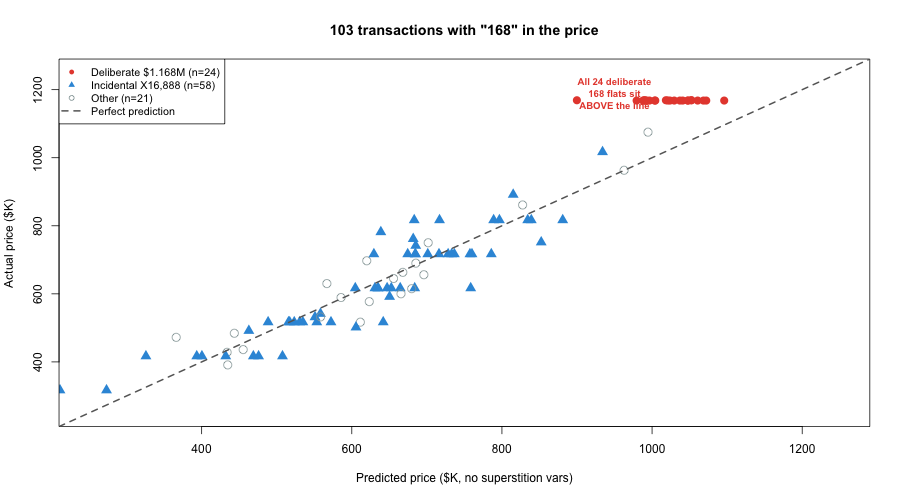

In [11]:
%%R -w 900 -h 500
# All 168 transactions: actual price vs predicted price, coloured by type
df_168 <- df[df$price_has_168 == 1, ]

df_168$type_168 <- ifelse(
    df_168$resale_price >= 1168000 & df_168$resale_price <= 1168888,
    'Deliberate ($1.168M)',
    ifelse(df_168$resale_price %% 1000 == 888 | df_168$resale_price %% 1000 == 688,
        'Incidental (X16,888)',
        'Other 168'))

df_168$pred_base <- predict(model_base, df_168)

# Colour map
cols <- ifelse(df_168$type_168 == 'Deliberate ($1.168M)', '#e74c3c',
        ifelse(df_168$type_168 == 'Incidental (X16,888)', '#3498db', '#95a5a6'))
pchs <- ifelse(df_168$type_168 == 'Deliberate ($1.168M)', 16,
         ifelse(df_168$type_168 == 'Incidental (X16,888)', 17, 1))

plot(df_168$pred_base / 1000, df_168$resale_price / 1000,
     col = cols, pch = pchs, cex = 1.5,
     xlab = 'Predicted price ($K, no superstition vars)',
     ylab = 'Actual price ($K)',
     main = '103 transactions with "168" in the price',
     xlim = c(250, 1250), ylim = c(250, 1250))
abline(0, 1, col = 'grey40', lwd = 2, lty = 2)

legend('topleft',
    c(sprintf('Deliberate $1.168M (n=%d)', sum(df_168$type_168 == 'Deliberate ($1.168M)')),
      sprintf('Incidental X16,888 (n=%d)', sum(df_168$type_168 == 'Incidental (X16,888)')),
      sprintf('Other (n=%d)', sum(df_168$type_168 == 'Other 168')),
      'Perfect prediction'),
    col = c('#e74c3c', '#3498db', '#95a5a6', 'grey40'),
    pch = c(16, 17, 1, NA), lty = c(NA, NA, NA, 2), lwd = c(NA, NA, NA, 2),
    cex = 0.9, bg = 'white')

# Annotate: the deliberate cluster sits above the line
text(950, 1190, 'All 24 deliberate\n168 flats sit\nABOVE the line',
     col = '#e74c3c', cex = 0.8, font = 2)

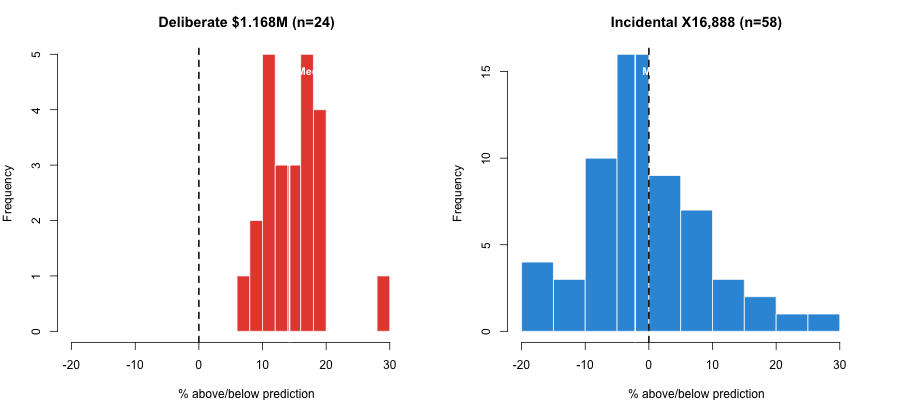

In [12]:
%%R -w 900 -h 400
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Deliberate: histogram of % gap
deliberate <- df_168[df_168$type_168 == 'Deliberate ($1.168M)', ]
deliberate$gap_pct <- (deliberate$resale_price - deliberate$pred_base) / deliberate$pred_base * 100

hist(deliberate$gap_pct, breaks = 15, col = '#e74c3c', border = 'white',
     main = sprintf('Deliberate $1.168M (n=%d)', nrow(deliberate)),
     xlab = '% above/below prediction',
     xlim = c(-20, 35))
abline(v = 0, col = 'black', lwd = 2, lty = 2)
abline(v = median(deliberate$gap_pct), col = 'white', lwd = 2)
text(median(deliberate$gap_pct), par('usr')[4] * 0.9,
     sprintf('Median: +%.1f%%', median(deliberate$gap_pct)),
     col = 'white', cex = 0.9, font = 2, pos = 4)

# Incidental: histogram of % gap
incidental <- df_168[df_168$type_168 == 'Incidental (X16,888)', ]
incidental$gap_pct <- (incidental$resale_price - incidental$pred_base) / incidental$pred_base * 100

hist(incidental$gap_pct, breaks = 15, col = '#3498db', border = 'white',
     main = sprintf('Incidental X16,888 (n=%d)', nrow(incidental)),
     xlab = '% above/below prediction',
     xlim = c(-20, 35))
abline(v = 0, col = 'black', lwd = 2, lty = 2)
abline(v = median(incidental$gap_pct), col = 'white', lwd = 2)
text(median(incidental$gap_pct), par('usr')[4] * 0.9,
     sprintf('Median: %+.1f%%', median(incidental$gap_pct)),
     col = 'white', cex = 0.9, font = 2, pos = 4)

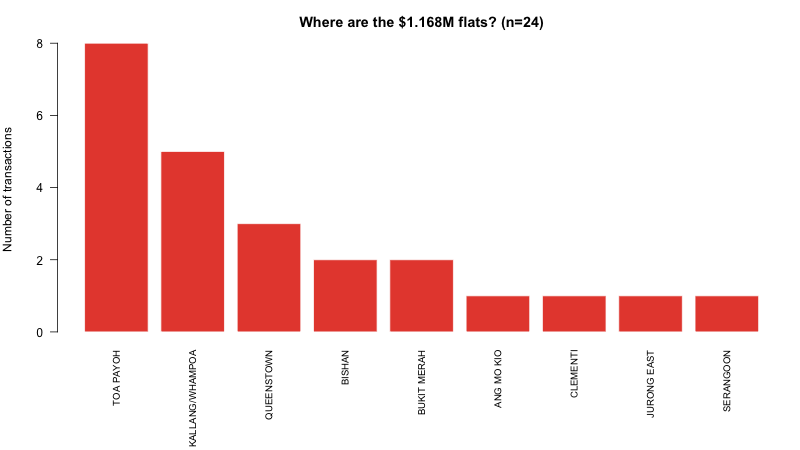

In [13]:
%%R -w 800 -h 450
# Where are the $1.168M flats? Bar chart by town
town_counts <- table(deliberate$town)
town_counts <- sort(town_counts, decreasing = TRUE)

par(mar = c(8, 4, 3, 1))
barplot(town_counts, las = 2, col = '#e74c3c', border = 'white',
        main = sprintf('Where are the $1.168M flats? (n=%d)', nrow(deliberate)),
        ylab = 'Number of transactions',
        cex.names = 0.8)

In [14]:
%%R
# Final comparison: how does the deliberate 168 group compare to
# (a) all flats with 3+ trailing 8s, and (b) all flats with no 8s?

# Reconstruct Model 12
model12 <- lm(resale_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              month_factor,
            data = df)

df$pred12 <- predict(model12, df)
df$resid12 <- df$resale_price - df$pred12
df$resid12_pct <- round(df$resid12 / df$pred12 * 100, 1)

# Groups
groups <- list(
    list('All flats (baseline)', df),
    list('No trailing 8s', df[df$num_eights_tail == 0, ]),
    list('1-2 trailing 8s', df[df$num_eights_tail >= 1 & df$num_eights_tail <= 2, ]),
    list('3+ trailing 8s', df[df$num_eights_tail >= 3, ]),
    list('Incidental 168 (X16,888)', df[df$price_has_168 == 1 &
        df$resale_price < 1168000, ]),
    list('Deliberate 168 ($1.168M)', df[df$price_has_168 == 1 &
        df$resale_price >= 1168000 & df$resale_price <= 1168888, ])
)

cat(sprintf('%-30s %7s %12s %12s %10s %8s\n',
    'Group', 'N', 'Avg price', 'Avg pred', 'Avg gap', '% above'))
cat(paste(rep('=', 82), collapse = ''), '\n')

for (g in groups) {
    label <- g[[1]]
    subset <- g[[2]]
    avg_gap <- mean(subset$resid12_pct)
    pct_above <- mean(subset$resid12 > 0) * 100
    cat(sprintf('%-30s %7s $%10s $%10s %+8.1f%% %7.0f%%\n',
        label,
        format(nrow(subset), big.mark = ','),
        format(round(mean(subset$resale_price)), big.mark = ','),
        format(round(mean(subset$pred12)), big.mark = ','),
        avg_gap,
        pct_above))
}

Group                                N    Avg price     Avg pred    Avg gap  % above


All flats (baseline)            50,718 $   642,432 $   642,432     +0.3%      48%


No trailing 8s                  38,858 $   636,020 $   636,246     +0.3%      48%


1-2 trailing 8s                  7,455 $   654,937 $   653,169     +0.5%      49%


3+ trailing 8s                   4,405 $   677,834 $   678,830     -0.2%      47%


Incidental 168 (X16,888)            79 $   623,692 $   624,435     +0.3%      44%


Deliberate 168 ($1.168M)            24 $ 1,168,192 $ 1,077,639     +8.6%     100%
